# 2023년 자치구별 주민부담률 분석

대시보드 연동용 CSV 생성 + 분자/분모 분해 분석

- 2023년 고정
- 전체 / 생활계 / 음식물 주민부담률 — 분자·분모 각각 분해
- 최종 CSV: `data/final/burden_rate_2023.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

from pathlib import Path

BASE  = Path('../data')
RAW   = BASE / 'raw'
PROC  = BASE / 'processed'
FINAL = BASE / 'final'

def _f(val, default=0.0):
    try:
        v = float(val)
        return v if not np.isnan(v) else default
    except Exception:
        return default

print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드

In [2]:
def load_total_burden():
    """서울시_주민부담률.xlsx — 전체 주민부담률"""
    df = pd.read_excel(RAW / '서울시_주민부담률.xlsx', header=None)
    recs = []
    for i in range(5, len(df)):
        gu = str(df.iloc[i, 1]).strip()
        if '합계' in gu or gu == 'nan':
            continue
        recs.append({
            'gu':           gu,
            'burden_total': _f(df.iloc[i, 2], np.nan),
        })
    return pd.DataFrame(recs)


def load_gen_burden():
    """서울시_생활폐기물_주민부담률.xlsx — 생활계 주민부담률 + 분자/분모"""
    df = pd.read_excel(RAW / '서울시_생활폐기물_주민부담률.xlsx', header=None)
    recs = []
    for i in range(5, len(df)):
        gu = str(df.iloc[i, 1]).strip()
        if '합계' in gu or gu == 'nan':
            continue
        recs.append({
            'gu':             gu,
            'burden_general': _f(df.iloc[i, 2], np.nan),  # 주민부담률
            'bag_rev':        _f(df.iloc[i, 3]),           # 분자: 종량제봉투 판매액 (백만원)
            'col_gen':        _f(df.iloc[i, 5]),           # 분모: 수집운반처리비 (백만원)
        })
    return pd.DataFrame(recs)


def load_food_burden():
    """서울시_음식물류폐기물_주민부담률.xlsx — 음식물 주민부담률 + 분자/분모"""
    df = pd.read_excel(RAW / '서울시_음식물류폐기물_주민부담률.xlsx', header=None)
    recs = []
    for i in range(5, len(df)):
        gu = str(df.iloc[i, 1]).strip()
        if '합계' in gu or gu == 'nan':
            continue
        recs.append({
            'gu':           gu,
            'burden_food':  _f(df.iloc[i, 2], np.nan),  # 주민부담률
            'fee_rev':      _f(df.iloc[i, 3]),           # 분자: 수수료 수입 (백만원)
            'col_food':     _f(df.iloc[i, 5]),           # 분모: 수집운반처리비 (백만원)
        })
    return pd.DataFrame(recs)


dt = load_total_burden()
dg = load_gen_burden()
df_food = load_food_burden()

print('전체 주민부담률:', len(dt), '구')
print('생활계 주민부담률:', len(dg), '구')
print('음식물 주민부담률:', len(df_food), '구')
print()
print(dt.head(3))

전체 주민부담률: 25 구
생활계 주민부담률: 25 구
음식물 주민부담률: 25 구

    gu  burden_total
0  종로구      0.288460
1   중구      0.244886
2  용산구      0.363107


In [3]:
# 2023년 인구·세대 데이터
_pop_raw = pd.read_csv(BASE.parent / '등록인구_20260429195432.csv',
                       skiprows=2, header=None, encoding='utf-8')
_pop_raw.columns = ['region', 'gu', 'year', 'households', 'total_pop',
                    'male', 'female', 'kor_total', 'kor_male', 'kor_female',
                    'foreign_total', 'foreign_male', 'foreign_female',
                    'persons_per_hh', 'elderly']
pop2023 = (_pop_raw[(_pop_raw['gu'] != '소계') & (_pop_raw['year'] == 2023)]
           [['gu', 'total_pop', 'households']].copy())

# 클러스터 유형
cluster_df = pd.read_csv(FINAL / 'cluster_result (2).csv', encoding='utf-8-sig')[
    ['gu', 'cluster_anchor', 'cluster_type']
]

print('2023년 인구 데이터:', len(pop2023), '구')
print('클러스터 유형별 구 수:')
print(cluster_df.groupby(['cluster_anchor', 'cluster_type'])['gu'].count().to_string())

2023년 인구 데이터: 25 구
클러스터 유형별 구 수:
cluster_anchor  cluster_type
0               상업형             6
1               주거형             8
2               유동집중형           5
3               혼합형             6


## 2. 마스터 DataFrame 구성 및 CSV 저장

In [4]:
master = (
    dt
    .merge(dg,         on='gu', how='outer')
    .merge(df_food,    on='gu', how='outer')
    .merge(pop2023,    on='gu', how='left')
    .merge(cluster_df, on='gu', how='left')
    .sort_values('gu')
    .reset_index(drop=True)
)

# 퍼센트 컬럼
master['burden_total_pct']   = (master['burden_total']   * 100).round(2)
master['burden_general_pct'] = (master['burden_general'] * 100).round(2)
master['burden_food_pct']    = (master['burden_food']    * 100).round(2)

# ── 생활계 분자/분모 ── 인구 기준(per_pop) · 세대 기준(per_hh) 모두 생성
master['bag_rev_per_pop'] = (master['bag_rev'] * 1e6 / master['total_pop']).round(0)   # 분자·인구당
master['bag_rev_per_hh']  = (master['bag_rev'] * 1e6 / master['households']).round(0)  # 분자·세대당
master['col_gen_per_pop'] = (master['col_gen'] * 1e6 / master['total_pop']).round(0)   # 분모·인구당
master['col_gen_per_hh']  = (master['col_gen'] * 1e6 / master['households']).round(0)  # 분모·세대당

# ── 음식물 분자/분모 ── 인구 기준(per_pop) · 세대 기준(per_hh) 모두 생성
master['fee_rev_per_pop']   = (master['fee_rev']  * 1e6 / master['total_pop']).round(0)
master['fee_rev_per_hh']    = (master['fee_rev']  * 1e6 / master['households']).round(0)
master['col_food_per_pop']  = (master['col_food'] * 1e6 / master['total_pop']).round(0)
master['col_food_per_hh']   = (master['col_food'] * 1e6 / master['households']).round(0)

# RFID 여부
master['rfid'] = master['fee_rev'] == 0

print('마스터 DataFrame:', master.shape)
print(master[['gu', 'cluster_type', 'burden_total_pct',
              'burden_general_pct', 'burden_food_pct']].to_string(index=False))

마스터 DataFrame: (25, 24)
  gu cluster_type  burden_total_pct  burden_general_pct  burden_food_pct
 강남구          상업형             35.38               46.08            32.02
 강동구        유동집중형             44.90               37.98            66.15
 강북구        유동집중형             32.32               37.08            39.63
 강서구          혼합형             32.84               45.57            41.61
 관악구          주거형             34.62               40.83            32.15
 광진구        유동집중형             25.20               49.76            27.29
 구로구          혼합형             29.92               33.99            24.68
 금천구          혼합형             15.28               32.02            27.18
 노원구          주거형             23.02               37.89            41.06
 도봉구          주거형             20.82               19.31            29.05
동대문구        유동집중형             31.09               38.14            30.26
 동작구          주거형             17.95               31.32            29.08
 마포구          혼합형          

In [5]:
# CSV 저장 — 대시보드용
out_cols = [
    'gu', 'cluster_type',
    'burden_total', 'burden_general', 'burden_food',
    'burden_total_pct', 'burden_general_pct', 'burden_food_pct',
    'total_pop', 'households',
    # 생활계 분자/분모 (인구당·세대당)
    'bag_rev', 'col_gen',
    'bag_rev_per_pop', 'bag_rev_per_hh',
    'col_gen_per_pop', 'col_gen_per_hh',
    # 음식물 분자/분모 (인구당·세대당)
    'fee_rev', 'col_food',
    'fee_rev_per_pop', 'fee_rev_per_hh',
    'col_food_per_pop', 'col_food_per_hh',
    'rfid',
]

save_df = master[out_cols].copy()
save_path = FINAL / 'burden_rate_2023.csv'
save_df.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f'저장 완료: {save_path}')
print(f'컬럼 수: {len(save_df.columns)}, 행 수: {len(save_df)}')

저장 완료: ..\data\final\burden_rate_2023.csv
컬럼 수: 23, 행 수: 25


## 3. 시각화 — 25개 자치구 주민부담률 비교

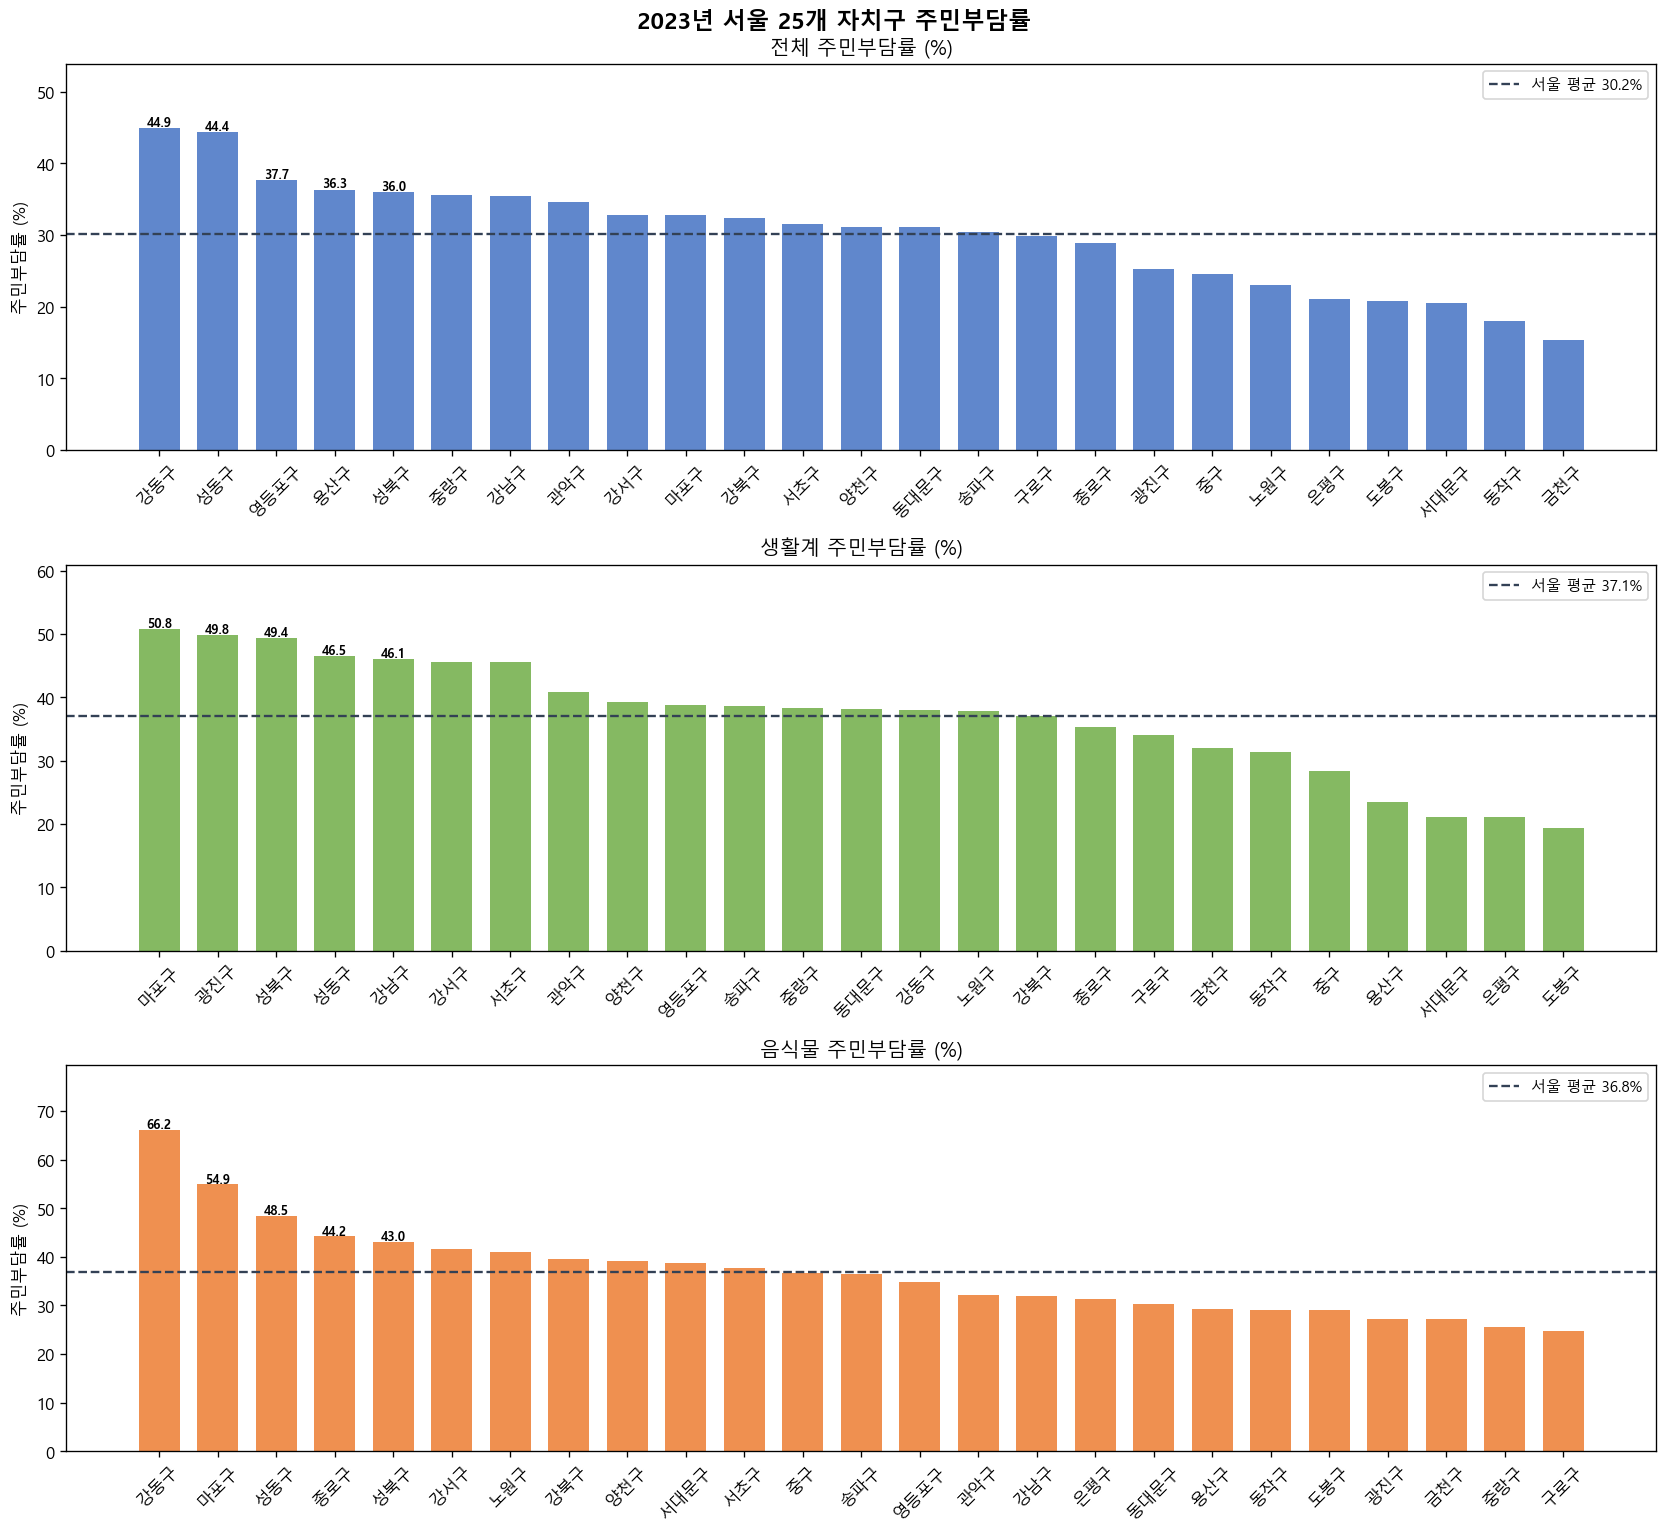

전체  — 서울 평균: 30.2%  최대: 44.9%  최소: 15.3%
생활계 — 서울 평균: 37.1%  최대: 50.8%  최소: 19.3%
음식물 — 서울 평균: 36.8%  최대: 66.2%  최소: 24.7%


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

mean_total   = master['burden_total_pct'].mean()
mean_general = master['burden_general_pct'].mean()
mean_food    = master['burden_food_pct'].mean()

def draw_bar(ax, col, mean_val, title, color):
    ds = master.sort_values(col, ascending=False)
    bars = ax.bar(ds['gu'], ds[col], color=color, width=0.7, alpha=0.85)
    ax.axhline(mean_val, color='#334155', linewidth=1.4, linestyle='--',
               label=f'서울 평균 {mean_val:.1f}%')
    ax.set_ylabel('주민부담률 (%)')
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    ax.set_ylim(0, ds[col].max() * 1.2)
    for bar, val in zip(bars, ds[col]):
        if val >= ds[col].quantile(0.8):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                    f'{val:.1f}', ha='center', fontsize=7.5, fontweight='bold')

draw_bar(axes[0], 'burden_total_pct',   mean_total,   '전체 주민부담률 (%)',   '#4472C4')
draw_bar(axes[1], 'burden_general_pct', mean_general, '생활계 주민부담률 (%)', '#70AD47')
draw_bar(axes[2], 'burden_food_pct',    mean_food,    '음식물 주민부담률 (%)', '#ED7D31')

plt.suptitle('2023년 서울 25개 자치구 주민부담률', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'전체  — 서울 평균: {mean_total:.1f}%  최대: {master["burden_total_pct"].max():.1f}%  최소: {master["burden_total_pct"].min():.1f}%')
print(f'생활계 — 서울 평균: {mean_general:.1f}%  최대: {master["burden_general_pct"].max():.1f}%  최소: {master["burden_general_pct"].min():.1f}%')
print(f'음식물 — 서울 평균: {mean_food:.1f}%  최대: {master["burden_food_pct"].max():.1f}%  최소: {master["burden_food_pct"].min():.1f}%')

## 4. 생활계 주민부담률 — 분자/분모 분해

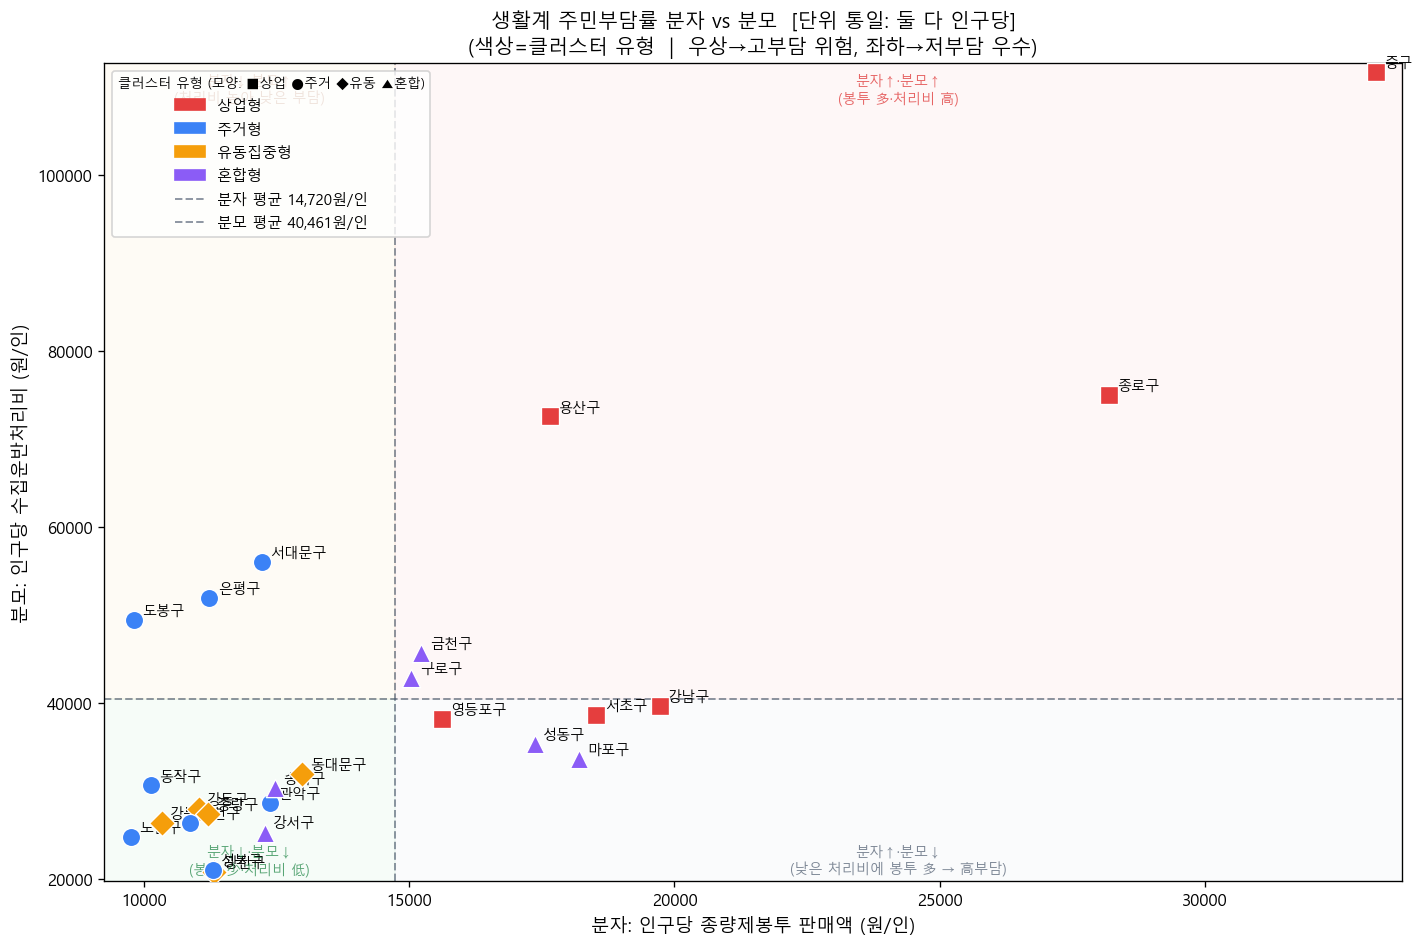

=== 생활계 분자/분모 사분면 분류 ===
  [분자↑·분모↑] 구로구, 금천구, 용산구, 종로구, 중구
  [분자↑·분모↓] 강남구, 마포구, 서초구, 성동구, 영등포구
  [분자↓·분모↑] 도봉구, 서대문구, 은평구
  [분자↓·분모↓] 강동구, 강북구, 강서구, 관악구, 광진구, 노원구, 동대문구, 동작구, 성북구, 송파구, 양천구, 중랑구


In [8]:
# 생활계: 분자 vs 분모 — 단위 통일 (둘 다 인구당) + 클러스터 색상
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

CLUSTER_COLORS   = {'상업형': '#e53e3e', '주거형': '#3b82f6',
                    '유동집중형': '#f59e0b', '혼합형': '#8b5cf6'}
CLUSTER_MARKERS  = {'상업형': 's', '주거형': 'o', '유동집중형': 'D', '혼합형': '^'}

mean_x_g = master['bag_rev_per_pop'].mean()
mean_y_g = master['col_gen_per_pop'].mean()

fig, ax = plt.subplots(figsize=(12, 8))

# 사분면 배경
xmin, xmax = master['bag_rev_per_pop'].min()-500,  master['bag_rev_per_pop'].max()+500
ymin, ymax = master['col_gen_per_pop'].min()-1000, master['col_gen_per_pop'].max()+1000
ax.fill_betweenx([mean_y_g, ymax], xmin, mean_x_g, alpha=0.04, color='#f59e0b')  # 분자↓·분모↑ → 낮은부담
ax.fill_betweenx([mean_y_g, ymax], mean_x_g, xmax, alpha=0.04, color='#ef4444')  # 분자↑·분모↑
ax.fill_betweenx([ymin, mean_y_g], xmin, mean_x_g, alpha=0.04, color='#22c55e')  # 분자↓·분모↓ → 낮은부담
ax.fill_betweenx([ymin, mean_y_g], mean_x_g, xmax, alpha=0.04, color='#94a3b8')  # 분자↑·분모↓ → 높은부담

ax.axvline(mean_x_g, color='#475569', linewidth=1.2, linestyle='--', alpha=0.6,
           label=f'분자 평균 {mean_x_g:,.0f}원/인')
ax.axhline(mean_y_g, color='#475569', linewidth=1.2, linestyle='--', alpha=0.6,
           label=f'분모 평균 {mean_y_g:,.0f}원/인')

for _, row in master.iterrows():
    ct = row['cluster_type']
    c  = CLUSTER_COLORS.get(ct, '#888')
    mk = CLUSTER_MARKERS.get(ct, 'o')
    ax.scatter(row['bag_rev_per_pop'], row['col_gen_per_pop'],
               c=c, s=120, marker=mk, edgecolors='white', linewidths=0.8, zorder=5)
    ax.annotate(row['gu'], (row['bag_rev_per_pop'], row['col_gen_per_pop']),
                xytext=(5, 3), textcoords='offset points', fontsize=8.5)

# 사분면 라벨
kw = dict(fontsize=8.5, ha='center', style='italic', alpha=0.7)
ax.text((xmin+mean_x_g)/2, ymax*0.96, '분자↓·분모↑\n(처리비 높아 낮은 부담)', color='#92400e', **kw)
ax.text((mean_x_g+xmax)/2, ymax*0.96, '분자↑·분모↑\n(봉투 多·처리비 高)', color='#dc2626', **kw)
ax.text((xmin+mean_x_g)/2, ymin+800,  '분자↓·분모↓\n(봉투 少·처리비 低)', color='#15803d', **kw)
ax.text((mean_x_g+xmax)/2, ymin+800,  '분자↑·분모↓\n(낮은 처리비에 봉투 多 → 高부담)', color='#475569', **kw)

handles = [mpatches.Patch(color=v, label=k) for k, v in CLUSTER_COLORS.items()]
handles += [ax.get_legend_handles_labels()[0][-2], ax.get_legend_handles_labels()[0][-1]]
ax.legend(handles=handles, fontsize=9, loc='upper left',
          title='클러스터 유형 (모양: ■상업 ●주거 ◆유동 ▲혼합)', title_fontsize=8)

ax.set_xlabel('분자: 인구당 종량제봉투 판매액 (원/인)', fontsize=11)
ax.set_ylabel('분모: 인구당 수집운반처리비 (원/인)', fontsize=11)
ax.set_title('생활계 주민부담률 분자 vs 분모  [단위 통일: 둘 다 인구당]\n'
             '(색상=클러스터 유형  |  우상→고부담 위험, 좌하→저부담 우수)', fontsize=12)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
plt.tight_layout()
plt.show()

# 4사분면 분류 출력
master['gen_quad'] = master.apply(
    lambda r: ('분자↑' if r['bag_rev_per_pop'] >= mean_x_g else '분자↓') + '·' +
              ('분모↑' if r['col_gen_per_pop']  >= mean_y_g else '분모↓'), axis=1)
print('=== 생활계 분자/분모 사분면 분류 ===')
for q, grp in master.groupby('gen_quad'):
    print(f"  [{q}] {', '.join(grp['gu'].tolist())}")

## 5. 음식물 주민부담률 — 분자/분모 분해

RFID 방식 구 (봉투 수입 없음): []


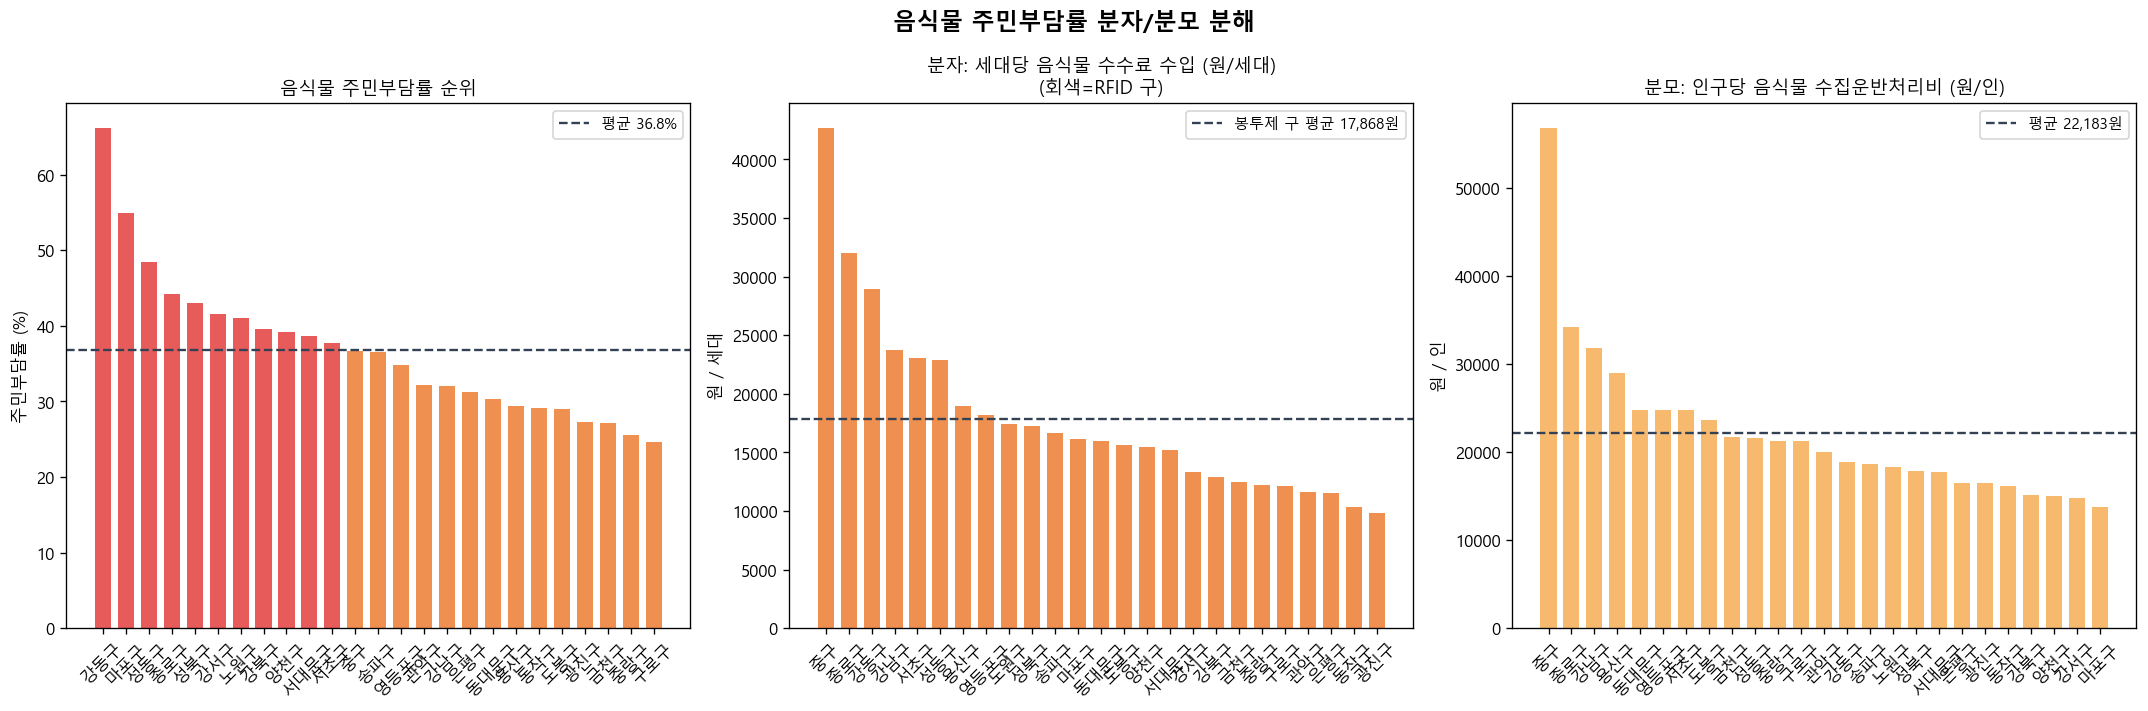

=== 음식물 분자/분모 요약 (봉투제 구 기준) ===
세대당 수수료 수입  — 평균: 17,868원  최대: 42,680원  최소: 9,813원
인구당 처리비용    — 평균: 22,183원  최대: 56,771원  최소: 13,762원


In [9]:
# RFID 구는 fee_rev = 0 → 별도 표시
master['rfid'] = master['fee_rev'] == 0
rfid_gu = master[master['rfid']]['gu'].tolist()
print('RFID 방식 구 (봉투 수입 없음):', rfid_gu)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('음식물 주민부담률 분자/분모 분해', fontsize=14, fontweight='bold')

mean_f = master['burden_food_pct'].mean()

# ① 주민부담률 순위
ax = axes[0]
ds = master.sort_values('burden_food_pct', ascending=False)
colors_f = ['#e53e3e' if v >= mean_f else '#ED7D31' for v in ds['burden_food_pct']]
bars = ax.bar(ds['gu'], ds['burden_food_pct'], color=colors_f, width=0.7, alpha=0.85)
ax.axhline(mean_f, color='#334155', linewidth=1.4, linestyle='--', label=f'평균 {mean_f:.1f}%')
ax.set_title('음식물 주민부담률 순위', fontsize=11)
ax.set_ylabel('주민부담률 (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

# ② 분자: 세대당 수수료 수입
ax2 = axes[1]
ds2 = master.sort_values('fee_rev_per_hh', ascending=False)
mean_fee_hh = master[master['fee_rev'] > 0]['fee_rev_per_hh'].mean()
bar_colors2 = ['#aaa' if g in rfid_gu else '#ED7D31' for g in ds2['gu']]
bars2 = ax2.bar(ds2['gu'], ds2['fee_rev_per_hh'], color=bar_colors2, width=0.7, alpha=0.85)
ax2.axhline(mean_fee_hh, color='#334155', linewidth=1.4, linestyle='--',
            label=f'봉투제 구 평균 {mean_fee_hh:,.0f}원')
ax2.set_title('분자: 세대당 음식물 수수료 수입 (원/세대)\n(회색=RFID 구)', fontsize=11)
ax2.set_ylabel('원 / 세대')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=9)

# ③ 분모: 인구당 처리비용
ax3 = axes[2]
ds3 = master.sort_values('col_food_per_pop', ascending=False)
mean_food_pop = master['col_food_per_pop'].mean()
bars3 = ax3.bar(ds3['gu'], ds3['col_food_per_pop'], color='#F6AD55', width=0.7, alpha=0.85)
ax3.axhline(mean_food_pop, color='#334155', linewidth=1.4, linestyle='--',
            label=f'평균 {mean_food_pop:,.0f}원')
ax3.set_title('분모: 인구당 음식물 수집운반처리비 (원/인)', fontsize=11)
ax3.set_ylabel('원 / 인')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('=== 음식물 분자/분모 요약 (봉투제 구 기준) ===')
valid = master[master['fee_rev'] > 0]
print(f'세대당 수수료 수입  — 평균: {valid["fee_rev_per_hh"].mean():,.0f}원  최대: {valid["fee_rev_per_hh"].max():,.0f}원  최소: {valid["fee_rev_per_hh"].min():,.0f}원')
print(f'인구당 처리비용    — 평균: {master["col_food_per_pop"].mean():,.0f}원  최대: {master["col_food_per_pop"].max():,.0f}원  최소: {master["col_food_per_pop"].min():,.0f}원')

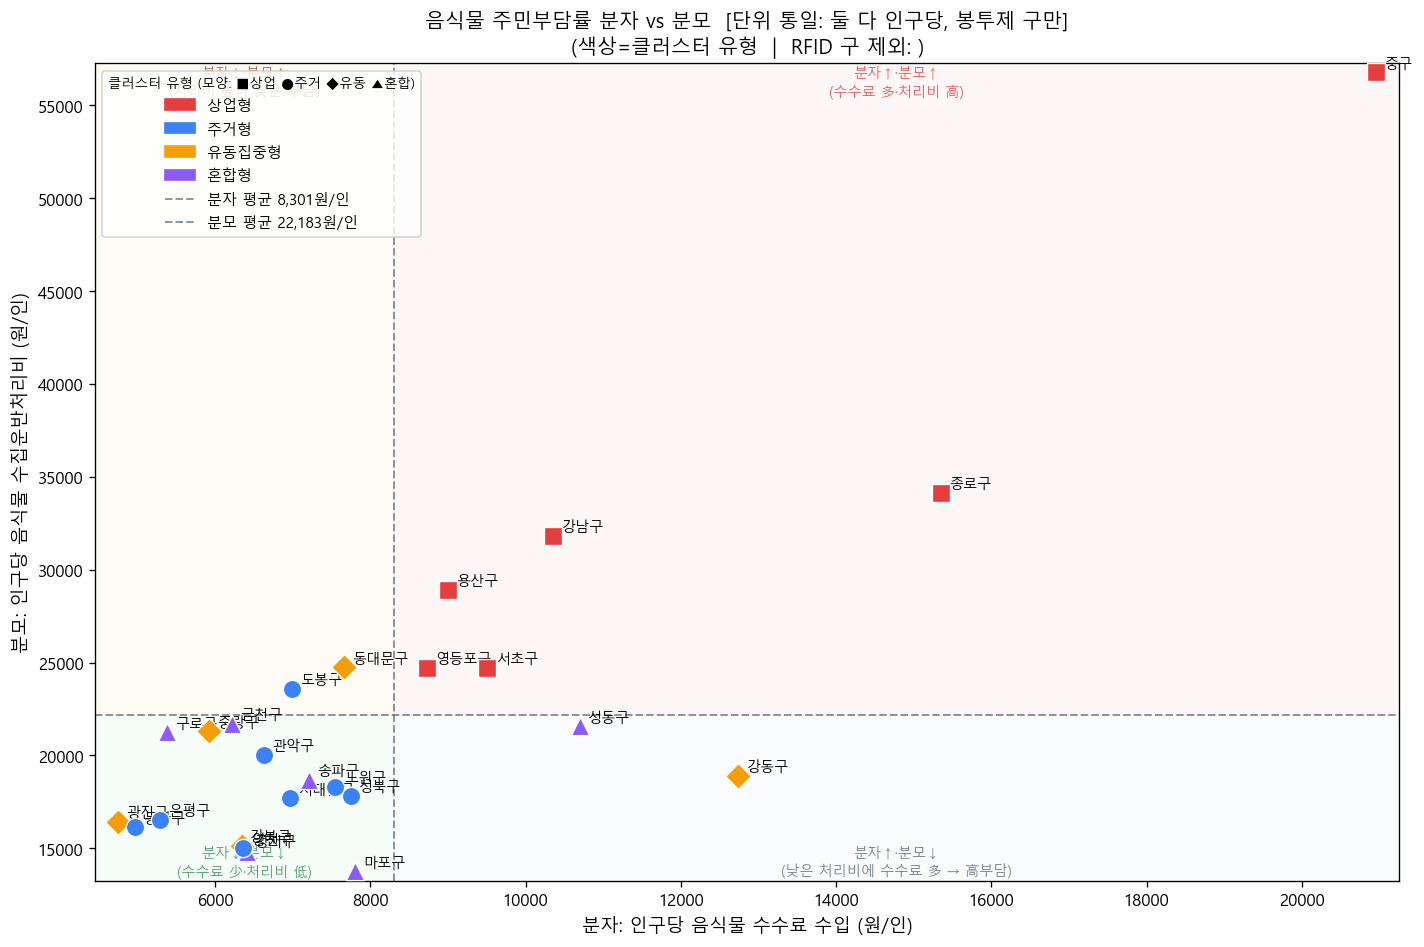

=== 음식물 분자/분모 사분면 분류 ===
  [분자↑·분모↑] 강남구, 서초구, 영등포구, 용산구, 종로구, 중구
  [분자↑·분모↓] 강동구, 성동구
  [분자↓·분모↑] 도봉구, 동대문구
  [분자↓·분모↓] 강북구, 강서구, 관악구, 광진구, 구로구, 금천구, 노원구, 동작구, 마포구, 서대문구, 성북구, 송파구, 양천구, 은평구, 중랑구


In [10]:
# 음식물: 분자 vs 분모 — 단위 통일 (둘 다 인구당), 봉투제 구만
valid_f = master[~master['rfid']].copy()

mean_x_f = valid_f['fee_rev_per_pop'].mean()
mean_y_f = valid_f['col_food_per_pop'].mean()

fig, ax = plt.subplots(figsize=(12, 8))

xmin_f = valid_f['fee_rev_per_pop'].min() - 300
xmax_f = valid_f['fee_rev_per_pop'].max() + 300
ymin_f = valid_f['col_food_per_pop'].min() - 500
ymax_f = valid_f['col_food_per_pop'].max() + 500

ax.fill_betweenx([mean_y_f, ymax_f], xmin_f, mean_x_f, alpha=0.04, color='#f59e0b')
ax.fill_betweenx([mean_y_f, ymax_f], mean_x_f, xmax_f, alpha=0.04, color='#ef4444')
ax.fill_betweenx([ymin_f, mean_y_f], xmin_f, mean_x_f, alpha=0.04, color='#22c55e')
ax.fill_betweenx([ymin_f, mean_y_f], mean_x_f, xmax_f, alpha=0.04, color='#94a3b8')

ax.axvline(mean_x_f, color='#475569', linewidth=1.2, linestyle='--', alpha=0.6,
           label=f'분자 평균 {mean_x_f:,.0f}원/인')
ax.axhline(mean_y_f, color='#475569', linewidth=1.2, linestyle='--', alpha=0.6,
           label=f'분모 평균 {mean_y_f:,.0f}원/인')

for _, row in valid_f.iterrows():
    ct = row['cluster_type']
    c  = CLUSTER_COLORS.get(ct, '#888')
    mk = CLUSTER_MARKERS.get(ct, 'o')
    ax.scatter(row['fee_rev_per_pop'], row['col_food_per_pop'],
               c=c, s=120, marker=mk, edgecolors='white', linewidths=0.8, zorder=5)
    ax.annotate(row['gu'], (row['fee_rev_per_pop'], row['col_food_per_pop']),
                xytext=(5, 3), textcoords='offset points', fontsize=8.5)

kw2 = dict(fontsize=8.5, ha='center', style='italic', alpha=0.7)
ax.text((xmin_f+mean_x_f)/2, ymax_f*0.97, '분자↓·분모↑\n(처리비 높아 낮은 부담)', color='#92400e', **kw2)
ax.text((mean_x_f+xmax_f)/2, ymax_f*0.97, '분자↑·분모↑\n(수수료 多·처리비 高)', color='#dc2626', **kw2)
ax.text((xmin_f+mean_x_f)/2, ymin_f+300,  '분자↓·분모↓\n(수수료 少·처리비 低)', color='#15803d', **kw2)
ax.text((mean_x_f+xmax_f)/2, ymin_f+300,  '분자↑·분모↓\n(낮은 처리비에 수수료 多 → 高부담)', color='#475569', **kw2)

handles_f = [mpatches.Patch(color=v, label=k) for k, v in CLUSTER_COLORS.items()]
handles_f += [ax.get_legend_handles_labels()[0][-2], ax.get_legend_handles_labels()[0][-1]]
ax.legend(handles=handles_f, fontsize=9, loc='upper left',
          title='클러스터 유형 (모양: ■상업 ●주거 ◆유동 ▲혼합)', title_fontsize=8)

ax.set_xlabel('분자: 인구당 음식물 수수료 수입 (원/인)', fontsize=11)
ax.set_ylabel('분모: 인구당 음식물 수집운반처리비 (원/인)', fontsize=11)
ax.set_title('음식물 주민부담률 분자 vs 분모  [단위 통일: 둘 다 인구당, 봉투제 구만]\n'
             '(색상=클러스터 유형  |  RFID 구 제외: ' +
             ', '.join(master[master['rfid']]['gu'].tolist()) + ')', fontsize=12)
ax.set_xlim(xmin_f, xmax_f)
ax.set_ylim(ymin_f, ymax_f)
plt.tight_layout()
plt.show()

master['food_quad'] = np.where(~master['rfid'],
    master.apply(
        lambda r: ('분자↑' if r['fee_rev_per_pop'] >= mean_x_f else '분자↓') + '·' +
                  ('분모↑' if r['col_food_per_pop'] >= mean_y_f else '분모↓'), axis=1),
    'RFID(봉투수입없음)')
print('=== 음식물 분자/분모 사분면 분류 ===')
for q, grp in master.groupby('food_quad'):
    print(f"  [{q}] {', '.join(grp['gu'].tolist())}")

## 7. 클러스터 유형별 주민부담률 분석 + 정책 시사점

=== 클러스터 유형별 평균 지표 ===
              burden_total_pct  burden_general_pct  burden_food_pct  bag_rev_per_pop  col_gen_per_pop  fee_rev_per_pop  col_food_per_pop
cluster_type                                                                                                                            
상업형                       32.4                36.3             35.8          22156.3          62583.8          12316.5           33524.7
주거형                       25.6                32.5             35.4          10955.4          36076.9           6562.9           18143.2
유동집중형                     33.8                40.3             37.8          11372.2          26879.8           7483.2           19302.8
혼합형                       30.9                41.2             38.9          15092.7          35502.5           7285.8           18628.7

서울 전체 평균:
burden_total_pct         30.2
burden_general_pct       37.1
burden_food_pct          36.8
bag_rev_per_pop       14719.9
col_gen_per_pop       40

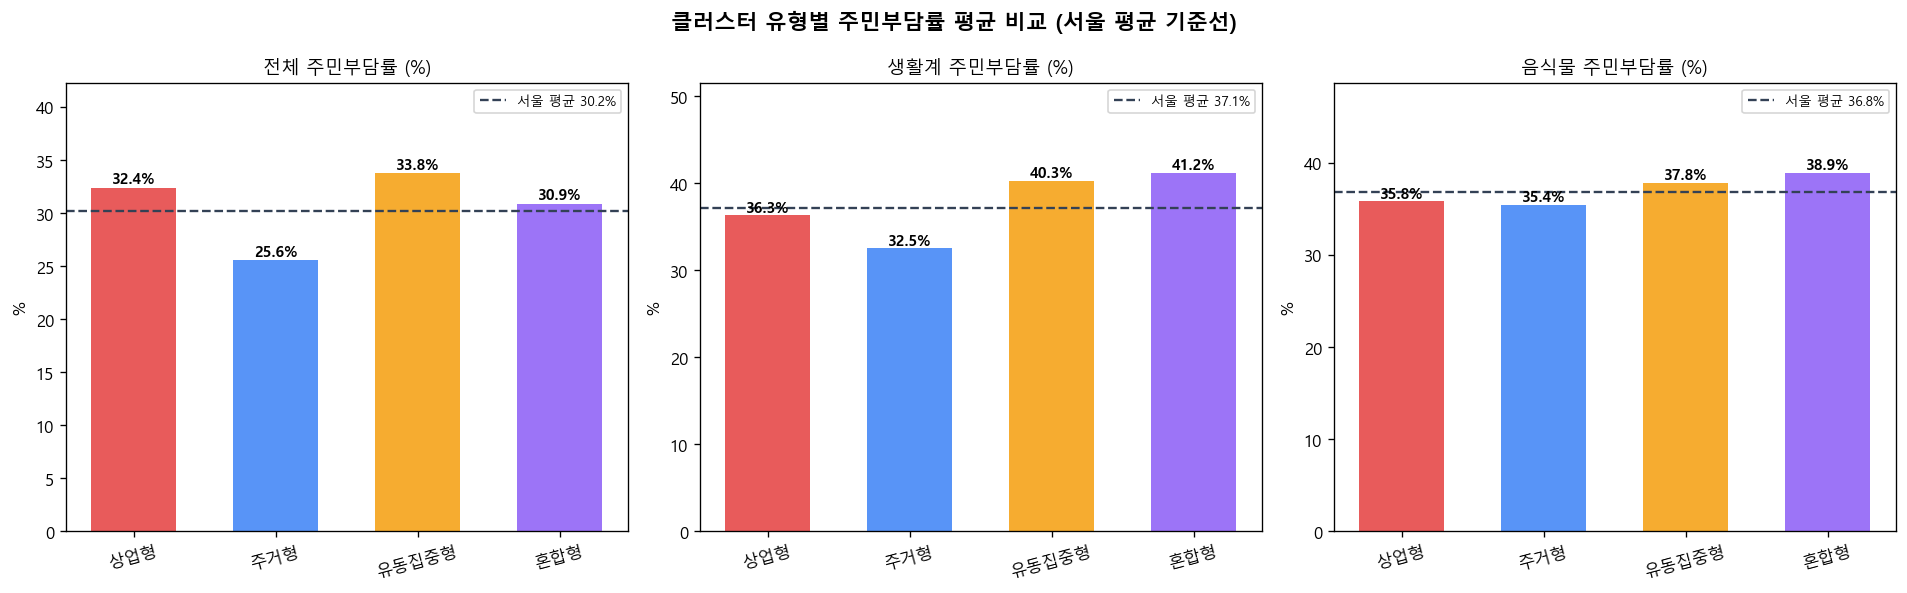

In [12]:
# ── 유형별 평균 지표 계산 ──────────────────────────────────────────────────
cluster_order = ['상업형', '주거형', '유동집중형', '혼합형']
cluster_mean = (master
                .groupby('cluster_type')[
                    ['burden_total_pct', 'burden_general_pct', 'burden_food_pct',
                     'bag_rev_per_pop', 'col_gen_per_pop',
                     'fee_rev_per_pop', 'col_food_per_pop']
                ].mean()
                .reindex(cluster_order)
                .round(1))

seoul_mean = master[['burden_total_pct', 'burden_general_pct', 'burden_food_pct',
                      'bag_rev_per_pop', 'col_gen_per_pop',
                      'fee_rev_per_pop', 'col_food_per_pop']].mean().round(1)

print('=== 클러스터 유형별 평균 지표 ===')
print(cluster_mean.to_string())
print()
print('서울 전체 평균:')
print(seoul_mean.to_string())

# ── 시각화 ①: 유형별 주민부담률 grouped bar ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('클러스터 유형별 주민부담률 평균 비교 (서울 평균 기준선)', fontsize=13, fontweight='bold')

metrics = [
    ('burden_total_pct',   '전체 주민부담률 (%)'),
    ('burden_general_pct', '생활계 주민부담률 (%)'),
    ('burden_food_pct',    '음식물 주민부담률 (%)'),
]
seoul_lines = [seoul_mean['burden_total_pct'],
               seoul_mean['burden_general_pct'],
               seoul_mean['burden_food_pct']]

for ax, (col, label), sl in zip(axes, metrics, seoul_lines):
    vals   = [cluster_mean.loc[ct, col] for ct in cluster_order]
    colors = [CLUSTER_COLORS[ct] for ct in cluster_order]
    bars   = ax.bar(cluster_order, vals, color=colors, alpha=0.85, width=0.6)
    ax.axhline(sl, color='#334155', linewidth=1.4, linestyle='--', label=f'서울 평균 {sl:.1f}%')
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('%')
    ax.set_ylim(0, max(vals + [sl]) * 1.25)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.4,
                f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

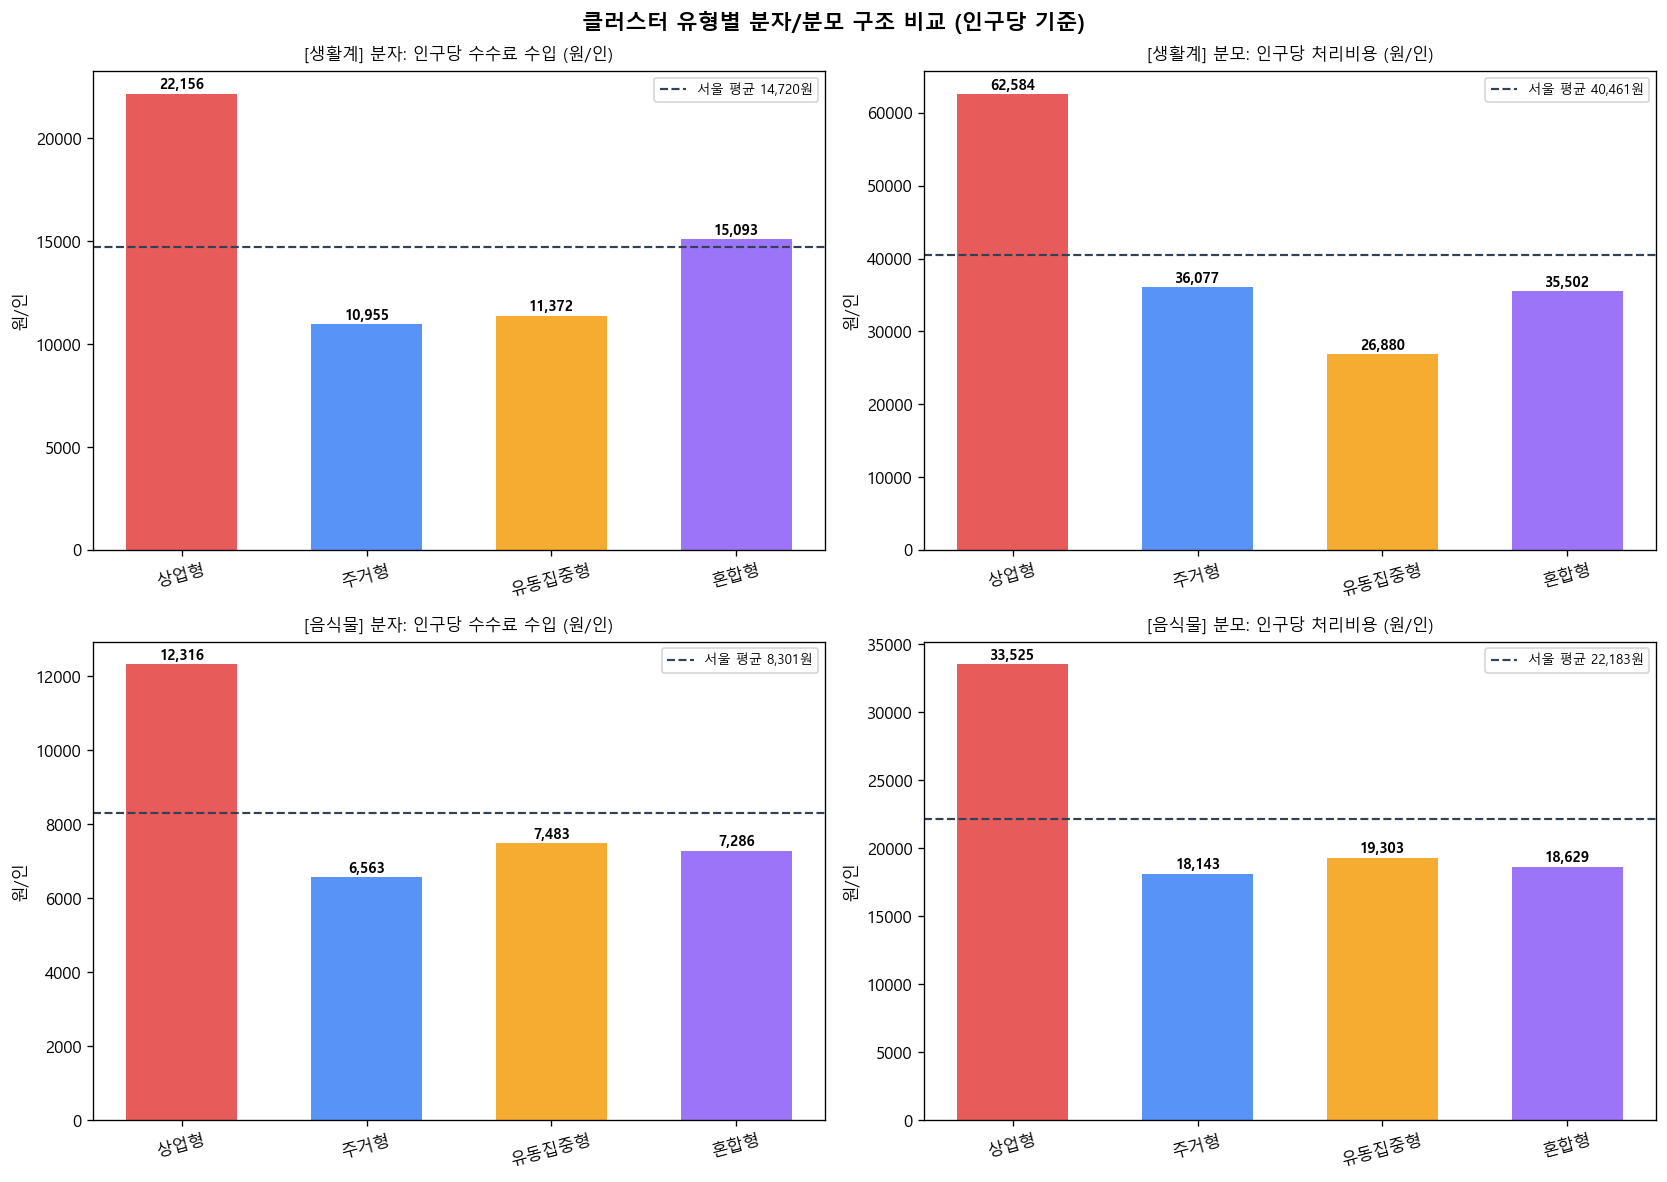

In [13]:
# ── 시각화 ②: 유형별 분자/분모 구조 — 인구당 기준 ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('클러스터 유형별 분자/분모 구조 비교 (인구당 기준)', fontsize=13, fontweight='bold')

decomp_metrics = [
    ('bag_rev_per_pop', 'col_gen_per_pop',
     '생활계: 인구당 분자(봉투판매액) vs 분모(처리비)', '#4472C4', '#70AD47'),
    ('fee_rev_per_pop', 'col_food_per_pop',
     '음식물: 인구당 분자(수수료수입) vs 분모(처리비)', '#ED7D31', '#F6AD55'),
]

for row_axes, (xcol, ycol, title, c_num, c_den) in zip(
        [axes[0], axes[1]], decomp_metrics):

    # 왼쪽: 분자 비교
    ax_l = row_axes[0]
    vals_n = [cluster_mean.loc[ct, xcol] for ct in cluster_order]
    colors_n = [CLUSTER_COLORS[ct] for ct in cluster_order]
    bars_n = ax_l.bar(cluster_order, vals_n, color=colors_n, alpha=0.85, width=0.6)
    ax_l.axhline(seoul_mean[xcol], color='#334155', linewidth=1.3, linestyle='--',
                 label=f'서울 평균 {seoul_mean[xcol]:,.0f}원')
    ax_l.set_title(f'분자: 인구당 {xcol.split("_")[0].upper()} 수입 (원/인)', fontsize=10)
    ax_l.set_ylabel('원/인')
    ax_l.tick_params(axis='x', rotation=15)
    ax_l.legend(fontsize=8)
    for bar, v in zip(bars_n, vals_n):
        ax_l.text(bar.get_x()+bar.get_width()/2, v + seoul_mean[xcol]*0.015,
                  f'{v:,.0f}', ha='center', fontsize=8.5, fontweight='bold')

    # 오른쪽: 분모 비교
    ax_r = row_axes[1]
    vals_d = [cluster_mean.loc[ct, ycol] for ct in cluster_order]
    bars_d = ax_r.bar(cluster_order, vals_d, color=colors_n, alpha=0.85, width=0.6)
    ax_r.axhline(seoul_mean[ycol], color='#334155', linewidth=1.3, linestyle='--',
                 label=f'서울 평균 {seoul_mean[ycol]:,.0f}원')
    ax_r.set_title(f'분모: 인구당 처리비용 (원/인)', fontsize=10)
    ax_r.set_ylabel('원/인')
    ax_r.tick_params(axis='x', rotation=15)
    ax_r.legend(fontsize=8)
    for bar, v in zip(bars_d, vals_d):
        ax_r.text(bar.get_x()+bar.get_width()/2, v + seoul_mean[ycol]*0.015,
                  f'{v:,.0f}', ha='center', fontsize=8.5, fontweight='bold')

    # 제목 묶음
    row_axes[0].set_title(f'[{title.split(":")[0]}] 분자: 인구당 수수료 수입 (원/인)', fontsize=10)
    row_axes[1].set_title(f'[{title.split(":")[0]}] 분모: 인구당 처리비용 (원/인)', fontsize=10)

plt.tight_layout()
plt.show()

## 8. 통합 분석 대시보드 — 산점도 + 사분면 해석 + 클러스터 비교

### 핵심 메시지

> **같은 주민부담률이라도 클러스터 유형에 따라 원인과 해법이 전혀 다르다.**

- **고수입고비용형** (상업형·유동집중형·혼합형): 봉투 판매액이 높지만 처리비도 높다. 수입이 많은 것처럼 보이지만, 처리 비용 구조를 개선하지 않으면 부담률이 낮아지지 않는다. → **비용 효율화 + 재활용품 선별 강화** 우선

- **저수입저비용형** (주거형): 처리 규모와 수입 모두 낮다. 분리배출 참여를 높여 봉투 사용량을 줄이거나, RFID 확대로 정확한 종량제를 실현할 수 있다. → **RFID 확대 + 분리배출 품질 교육** 우선

- **재정부담형** (일부 구): 처리비가 높은데 수입이 낮다. 단순히 봉투 가격을 올려도 효과가 제한적이며, 수입원을 다변화하거나 광역 처리 협력을 검토해야 한다. → **수입원 발굴 + 처리 방식 전환** 시급

**결론**: 주민부담률은 단일 지표로 평가할 수 없으며, 분자(수입)와 분모(비용)를 분리하고 지역 특성(클러스터)을 함께 고려해야 실효성 있는 정책 설계가 가능하다.

---
## 9. 클러스터 유형 × 비용 부담 유형 — 매트릭스 산점도

**Y축**: 클러스터 유형 (도시 구조 기반, 4개)  
**X축**: 비용 부담 유형 (분자=인구당 봉투판매액 / 분모=인구당 처리비 사분면, 4개)  
→ **4 × 4 = 16개 정책 시나리오 조합**

| 비용 부담 유형 | 의미 | 정책 방향 |
|---|---|---|
| 분자↑·분모↑ (고수입고비용형) | 봉투 소비 多 + 처리비 高 | 비용 구조 개선 + 배출 감량 |
| 분자↑·분모↓ (수입회수형·高부담) | 낮은 처리비에 봉투 多 → 주민 부담↑ | 봉투 감량·RFID 전환 |
| 분자↓·분모↑ (재정부담형·低부담) | 처리비 高, 봉투 수입 少 → 구비 압박 | 처리비 절감·비용 분담 |
| 분자↓·분모↓ (저수입저비용형·효율) | 봉투·처리비 모두 낮음 → 효율 상태 | 현상 유지·재활용 품질 제고 |

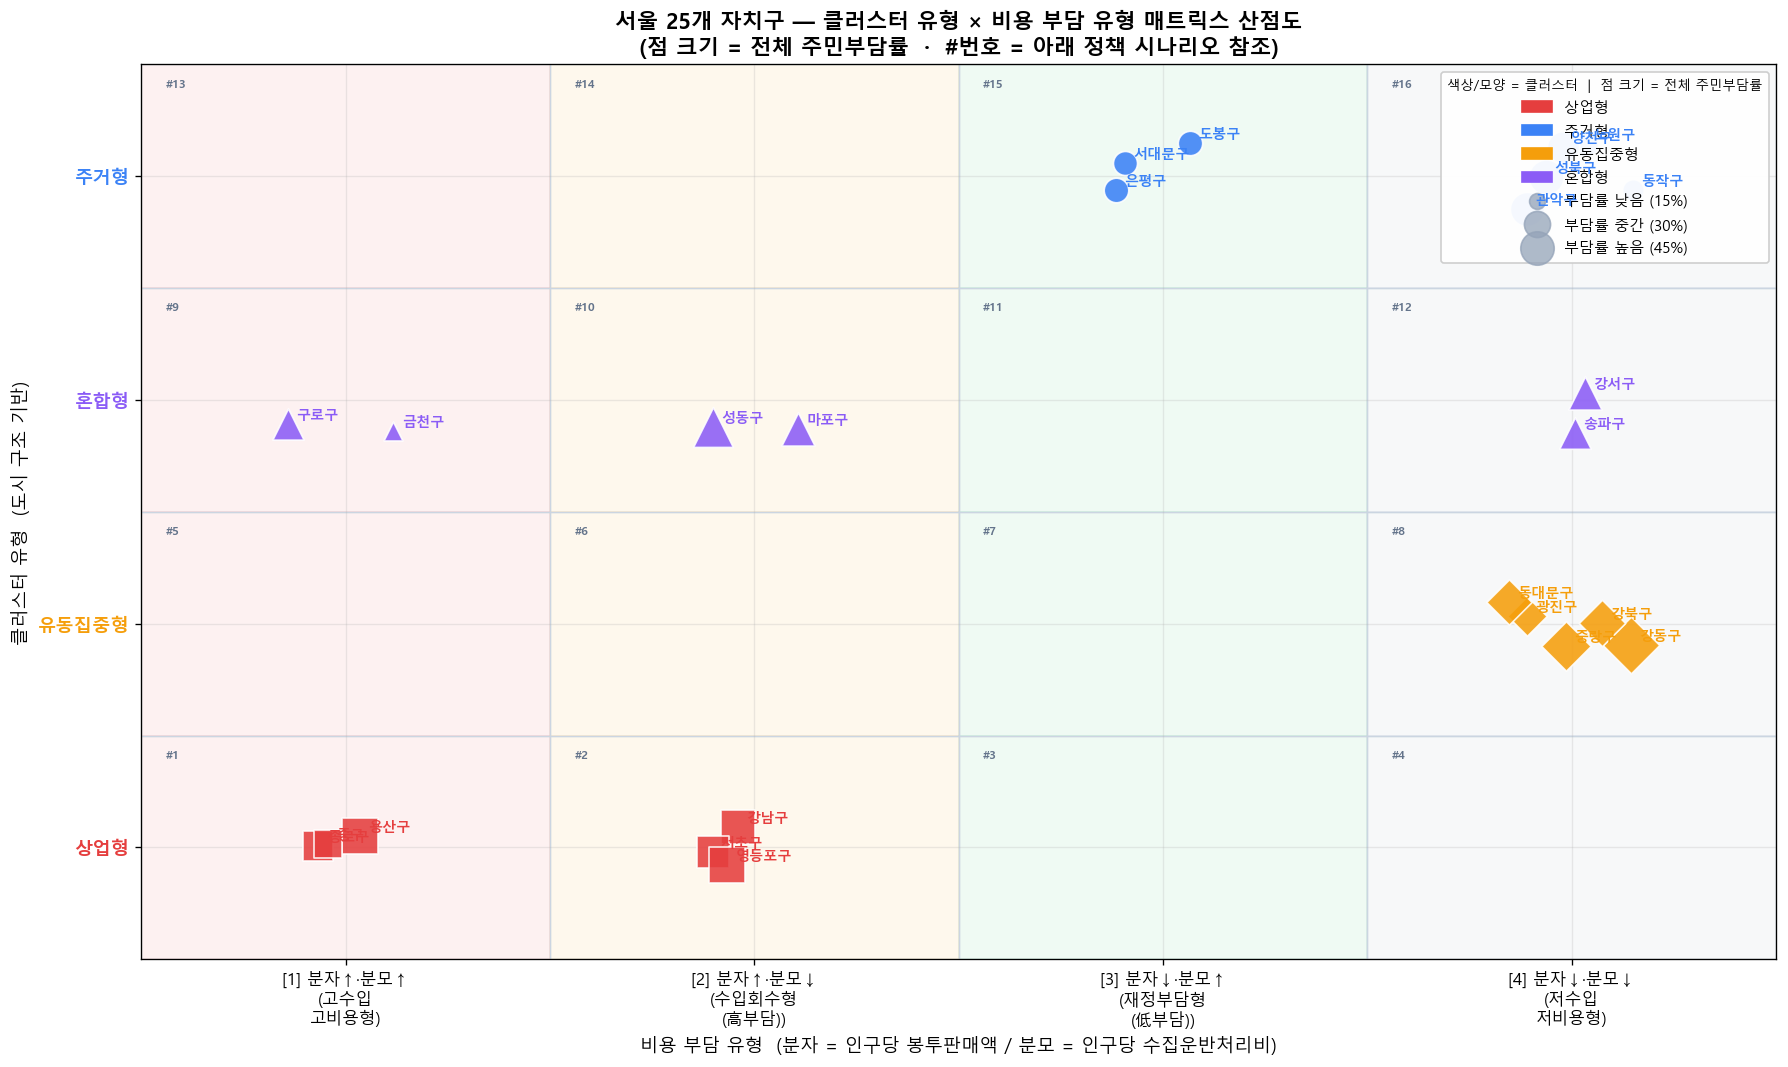


=== 클러스터 유형 × 비용 부담 유형 교차표 ===
  #01  [상업형] × [분자↑·분모↑]  (3개 구)  평균부담률 29.9%
        구: 용산구, 종로구, 중구
  #02  [상업형] × [분자↑·분모↓]  (3개 구)  평균부담률 34.9%
        구: 강남구, 서초구, 영등포구
  #03  [상업형] × [분자↓·분모↑]  (0개 구)
  #04  [상업형] × [분자↓·분모↓]  (0개 구)

  #05  [유동집중형] × [분자↑·분모↑]  (0개 구)
  #06  [유동집중형] × [분자↑·분모↓]  (0개 구)
  #07  [유동집중형] × [분자↓·분모↑]  (0개 구)
  #08  [유동집중형] × [분자↓·분모↓]  (5개 구)  평균부담률 33.8%
        구: 강동구, 강북구, 광진구, 동대문구, 중랑구

  #09  [혼합형] × [분자↑·분모↑]  (2개 구)  평균부담률 22.6%
        구: 구로구, 금천구
  #10  [혼합형] × [분자↑·분모↓]  (2개 구)  평균부담률 38.6%
        구: 마포구, 성동구
  #11  [혼합형] × [분자↓·분모↑]  (0개 구)
  #12  [혼합형] × [분자↓·분모↓]  (2개 구)  평균부담률 31.6%
        구: 강서구, 송파구

  #13  [주거형] × [분자↑·분모↑]  (0개 구)
  #14  [주거형] × [분자↑·분모↓]  (0개 구)
  #15  [주거형] × [분자↓·분모↑]  (3개 구)  평균부담률 20.8%
        구: 도봉구, 서대문구, 은평구
  #16  [주거형] × [분자↓·분모↓]  (5개 구)  평균부담률 28.5%
        구: 관악구, 노원구, 동작구, 성북구, 양천구



In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

# ─── 범주 정의 ─────────────────────────────────────────────────────────────
CLUSTER_ORDER = ['상업형', '유동집중형', '혼합형', '주거형']   # Y축 (위→아래)
BURDEN_ORDER  = ['분자↑·분모↑', '분자↑·분모↓', '분자↓·분모↑', '분자↓·분모↓']  # X축

BURDEN_LABELS = {
    '분자↑·분모↑': '고수입\n고비용형',
    '분자↑·분모↓': '수입회수형\n(高부담)',
    '분자↓·분모↑': '재정부담형\n(低부담)',
    '분자↓·분모↓': '저수입\n저비용형',
}

BURDEN_BG = {
    '분자↑·분모↑': '#ef4444',
    '분자↑·분모↓': '#f59e0b',
    '분자↓·분모↑': '#22c55e',
    '분자↓·분모↓': '#94a3b8',
}

CLUSTER_COLORS  = {'상업형': '#e53e3e', '주거형': '#3b82f6',
                   '유동집중형': '#f59e0b', '혼합형': '#8b5cf6'}
CLUSTER_MARKERS = {'상업형': 's', '주거형': 'o', '유동집중형': 'D', '혼합형': '^'}

# ─── 데이터 준비 ───────────────────────────────────────────────────────────
plot_df = master[master['gen_quad'].notna() & master['cluster_type'].notna()].copy()

burden_to_x  = {b: i for i, b in enumerate(BURDEN_ORDER)}
cluster_to_y = {c: i for i, c in enumerate(CLUSTER_ORDER)}

plot_df['_x'] = plot_df['gen_quad'].map(burden_to_x)
plot_df['_y'] = plot_df['cluster_type'].map(cluster_to_y)

# 지터 (같은 셀 내 여러 구 분산)
np.random.seed(42)
JITTER = 0.16
plot_df['_xj'] = plot_df['_x'] + np.random.uniform(-JITTER, JITTER, len(plot_df))
plot_df['_yj'] = plot_df['_y'] + np.random.uniform(-JITTER, JITTER, len(plot_df))

# 점 크기 = 전체 주민부담률
bmin, bmax = plot_df['burden_total_pct'].min(), plot_df['burden_total_pct'].max()
S_MIN, S_MAX = 130, 580
plot_df['_sz'] = S_MIN + (plot_df['burden_total_pct'] - bmin) / (bmax - bmin) * (S_MAX - S_MIN)

# ─── 시각화 ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 9))

# 배경 셀 색상
for xi, b in enumerate(BURDEN_ORDER):
    for yi in range(len(CLUSTER_ORDER)):
        ax.add_patch(plt.Rectangle((xi - 0.5, yi - 0.5), 1, 1,
                                    color=BURDEN_BG[b], alpha=0.07, zorder=0))
        # 셀 테두리
        ax.add_patch(plt.Rectangle((xi - 0.5, yi - 0.5), 1, 1,
                                    fill=False, edgecolor='#cbd5e1',
                                    linewidth=0.8, zorder=1))

# 점 그리기
for _, row in plot_df.iterrows():
    ct = row['cluster_type']
    c  = CLUSTER_COLORS.get(ct, '#888')
    mk = CLUSTER_MARKERS.get(ct, 'o')
    ax.scatter(row['_xj'], row['_yj'],
               c=c, s=row['_sz'], marker=mk,
               edgecolors='white', linewidths=1.0,
               alpha=0.88, zorder=5)
    ax.annotate(row['gu'], (row['_xj'], row['_yj']),
                xytext=(5, 3), textcoords='offset points',
                fontsize=8.5, zorder=6,
                color=CLUSTER_COLORS.get(ct, '#333'),
                fontweight='bold')

# 그리드
ax.set_xticks(range(len(BURDEN_ORDER)))
ax.set_yticks(range(len(CLUSTER_ORDER)))
ax.grid(True, alpha=0.25, linewidth=0.8, zorder=2)

# X축 레이블 (비용 부담 유형 + 간략 설명)
ax.set_xticklabels(
    [f"[{i+1}] {BURDEN_ORDER[i]}\n({BURDEN_LABELS[BURDEN_ORDER[i]]})"
     for i in range(len(BURDEN_ORDER))],
    fontsize=10
)

# Y축 레이블 (클러스터 유형)
ax.set_yticklabels(
    [f"{c}" for c in CLUSTER_ORDER],
    fontsize=11, fontweight='bold'
)
for lbl, ct in zip(ax.get_yticklabels(), CLUSTER_ORDER):
    lbl.set_color(CLUSTER_COLORS.get(ct, '#333'))

# 셀 번호 표시 (정책 시나리오 참조용)
scenario_num = 1
for yi, ct in enumerate(CLUSTER_ORDER):
    for xi, bq in enumerate(BURDEN_ORDER):
        ax.text(xi - 0.44, yi + 0.40, f'#{scenario_num}',
                fontsize=7, color='#64748b', fontweight='bold', zorder=7)
        scenario_num += 1

# 범례
legend_handles = [mpatches.Patch(color=v, label=k) for k, v in CLUSTER_COLORS.items()]
for lbl, pct in [('낮음', bmin), ('중간', (bmin+bmax)/2), ('높음', bmax)]:
    sz = S_MIN + (pct - bmin) / (bmax - bmin) * (S_MAX - S_MIN)
    legend_handles.append(
        mlines.Line2D([], [], linestyle='none', marker='o', color='#94a3b8',
                      markersize=(sz**0.5) / 1.2, alpha=0.75,
                      label=f'부담률 {lbl} ({pct:.0f}%)'))

ax.legend(handles=legend_handles, fontsize=9, loc='upper right',
          title='색상/모양 = 클러스터  |  점 크기 = 전체 주민부담률', title_fontsize=8,
          framealpha=0.95)

ax.set_xlabel('비용 부담 유형  (분자 = 인구당 봉투판매액 / 분모 = 인구당 수집운반처리비)',
              fontsize=11)
ax.set_ylabel('클러스터 유형  (도시 구조 기반)', fontsize=11)
ax.set_title('서울 25개 자치구 — 클러스터 유형 × 비용 부담 유형 매트릭스 산점도\n'
             '(점 크기 = 전체 주민부담률  · ',
             fontsize=13, fontweight='bold')

ax.set_xlim(-0.5, len(BURDEN_ORDER) - 0.5)
ax.set_ylim(-0.5, len(CLUSTER_ORDER) - 0.5)
plt.tight_layout()
plt.savefig('../../data/final/policy_matrix_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── 교차표 출력 ──────────────────────────────────────────────────────────
print('\n=== 클러스터 유형 × 비용 부담 유형 교차표 ===')
n = 1
for ct in CLUSTER_ORDER:
    for bq in BURDEN_ORDER:
        sub = plot_df[(plot_df['cluster_type']==ct) & (plot_df['gen_quad']==bq)]
        gus = ', '.join(sub['gu'].tolist()) if len(sub) > 0 else '(해당 없음)'
        avg = sub['burden_total_pct'].mean() if len(sub) > 0 else float('nan')
        print(f'  #{n:02d}  [{ct}] × [{bq}]  ({len(sub)}개 구)  '
              f'평균부담률 {avg:.1f}%' if len(sub)>0 else
              f'  #{n:02d}  [{ct}] × [{bq}]  (0개 구)')
        if len(sub) > 0:
            print(f'        구: {gus}')
        n += 1
    print()

---
## 11. ANOVA: 클러스터 유형별 1인당 판매량 · 비용 차이 검정

- **1인당 판매량** = `bag_rev_per_pop` (생활계 봉투 판매액 / 인구)
- **1인당 비용** = `col_gen_per_pop` (생활계 처리비 / 인구)
- 클러스터 4개 유형 간 평균 차이가 통계적으로 유의한지 일원분산분석(One-Way ANOVA)으로 검정

In [19]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
import numpy as np

cluster_order = ['상업형', '주거형', '유동집중형', '혼합형']

def run_anova(df, metric, label):
    groups = [df[df['cluster_type'] == c][metric].dropna().values for c in cluster_order]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = "*** 유의 (p<0.05)" if p_val < 0.05 else "비유의"
    print(f"\n[{label}] One-Way ANOVA")
    print(f"  F = {f_stat:.3f},  p = {p_val:.4f}  {sig}")
    summary = df.groupby('cluster_type')[metric].agg(['mean', 'std', 'count'])
    summary.columns = ['평균', '표준편차', 'N']
    summary = summary.reindex(cluster_order)
    summary['평균'] = summary['평균'].round(0).astype(int)
    summary['표준편차'] = summary['표준편차'].round(0).astype(int)
    print(summary.to_string())
    return f_stat, p_val

f1, p1 = run_anova(master, 'bag_rev_per_pop', '1인당 봉투판매액 (판매량)')
f2, p2 = run_anova(master, 'col_gen_per_pop', '1인당 생활계 처리비 (비용)')

# Tukey HSD post-hoc
print('\n' + '='*60)
print('[Post-hoc: Tukey HSD — 1인당 봉투판매액]')
tukey1 = pairwise_tukeyhsd(master['bag_rev_per_pop'].fillna(0), master['cluster_type'].fillna('미분류'))
print(tukey1.summary())

print('\n' + '='*60)
print('[Post-hoc: Tukey HSD — 1인당 생활계 처리비]')
tukey2 = pairwise_tukeyhsd(master['col_gen_per_pop'].fillna(0), master['cluster_type'].fillna('미분류'))
print(tukey2.summary())



[1인당 봉투판매액 (판매량)] One-Way ANOVA
  F = 12.457,  p = 0.0001  *** 유의 (p<0.05)
                 평균  표준편차  N
cluster_type                
상업형           22156  6948  6
주거형           10955  1017  8
유동집중형         11372   971  5
혼합형           15093  2439  6

[1인당 생활계 처리비 (비용)] One-Way ANOVA
  F = 4.790,  p = 0.0107  *** 유의 (p<0.05)
                 평균   표준편차  N
cluster_type                 
상업형           62584  29527  6
주거형           36077  13952  8
유동집중형         26880   4007  5
혼합형           35502   7664  6

[Post-hoc: Tukey HSD — 1인당 봉투판매액]
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj     lower      upper    reject
--------------------------------------------------------------
   상업형  유동집중형 -10784.1333 0.0005  -16970.296 -4597.9707   True
   상업형    주거형 -11200.9583 0.0001  -16718.289 -5683.6276   True
   상업형    혼합형  -7063.6667 0.0152 -12961.9413  -1165.392   True
 유동집중형    주거형    -416.825 0.9971  -6240.9045  5407.2545  False
 유동집중형    혼합형   37